In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

In [9]:
df_seer = pd.read_csv(r"C:\Rishit\Projects\Cancer-Analysis\data\raw\seer\seer_data.txt", 
                      low_memory=False)

print(f"Rows: {df_seer.shape[0]}")
print(f"Columns: {df_seer.shape[1]}")
print(f"\nColumn names:")
print(df_seer.columns.tolist())

Rows: 9187720
Columns: 8

Column names:
['Age recode with <1 year olds and 90+', 'Sex', 'Year of diagnosis', 'Race recode (W, B, AI, API)', 'Primary Site - labeled', 'Summary stage 2000 (1998-2017)', 'Survival months', 'Vital status recode (study cutoff used)']


In [10]:
# Filter for breast cancer only
df_breast = df_seer[df_seer['Primary Site - labeled'].str.contains('Breast', na=False)].copy()

print(f"Breast cancer patients: {df_breast.shape[0]}")
print(f"\nRace breakdown:")
print(df_breast['Race recode (W, B, AI, API)'].value_counts())

Breast cancer patients: 211348

Race breakdown:
Race recode (W, B, AI, API)
White                            166134
Black                             24585
Asian or Pacific Islander         16872
Unknown                            2345
American Indian/Alaska Native      1412
Name: count, dtype: int64


In [11]:
# Rename columns to simpler names
df_breast.columns = ['age', 'sex', 'year', 'race', 'primary_site', 'stage', 'survival_months', 'vital_status']

# Convert survival months to numeric
df_breast['survival_months'] = pd.to_numeric(df_breast['survival_months'], errors='coerce')

# Create event column (1 = died, 0 = alive)
df_breast['event'] = df_breast['vital_status'].apply(lambda x: 1 if x == 'Dead' else 0)

# Remove unknown race and missing survival
df_clean_seer = df_breast[
    (df_breast['race'] != 'Unknown') &
    (df_breast['survival_months'].notna())
].copy()

print(f"Patients after cleaning: {df_clean_seer.shape[0]}")
print(f"\nRace breakdown:")
print(df_clean_seer['race'].value_counts())
print(f"\nStage breakdown:")
print(df_clean_seer['stage'].value_counts())

Patients after cleaning: 203057

Race breakdown:
race
White                            161118
Black                             23961
Asian or Pacific Islander         16603
American Indian/Alaska Native      1375
Name: count, dtype: int64

Stage breakdown:
stage
Localized           72362
Regional            54447
Blank(s)            40265
Distant             22466
Unknown/unstaged    13517
Name: count, dtype: int64


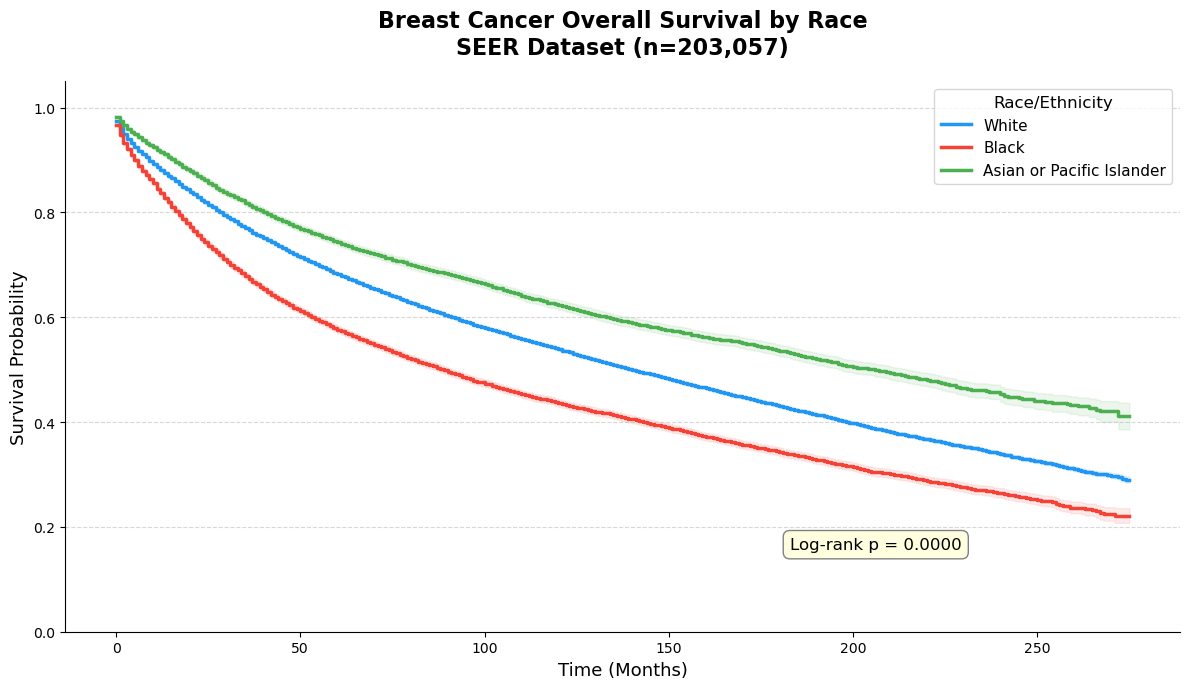

p-value: 0.000000


In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

races = ['White', 'Black', 'Asian or Pacific Islander']
colors = ['#2196F3', '#F44336', '#4CAF50']
labels = ['White', 'Black', 'Asian or Pacific Islander']

kmf = KaplanMeierFitter()

for race, color, label in zip(races, colors, labels):
    mask = df_clean_seer['race'] == race
    kmf.fit(df_clean_seer[mask]['survival_months'],
            event_observed=df_clean_seer[mask]['event'],
            label=label)
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2.5, ci_alpha=0.1)

# Log rank test
results = multivariate_logrank_test(
    df_clean_seer[df_clean_seer['race'].isin(races)]['survival_months'],
    df_clean_seer[df_clean_seer['race'].isin(races)]['race'],
    df_clean_seer[df_clean_seer['race'].isin(races)]['event']
)

ax.annotate(f'Log-rank p = {results.p_value:.4f}',
            xy=(0.65, 0.15), xycoords='axes fraction',
            fontsize=12,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

ax.set_title('Breast Cancer Overall Survival by Race\nSEER Dataset (n=203,057)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Time (Months)', fontsize=13)
ax.set_ylabel('Survival Probability', fontsize=13)
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Race/Ethnicity', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Rishit\Projects\Cancer-Analysis\figures\seer_survival_by_race.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"p-value: {results.p_value:.6f}")

In [13]:
# Check what stages we have
print(df_clean_seer['stage'].value_counts())

stage
Localized           72362
Regional            54447
Blank(s)            40265
Distant             22466
Unknown/unstaged    13517
Name: count, dtype: int64


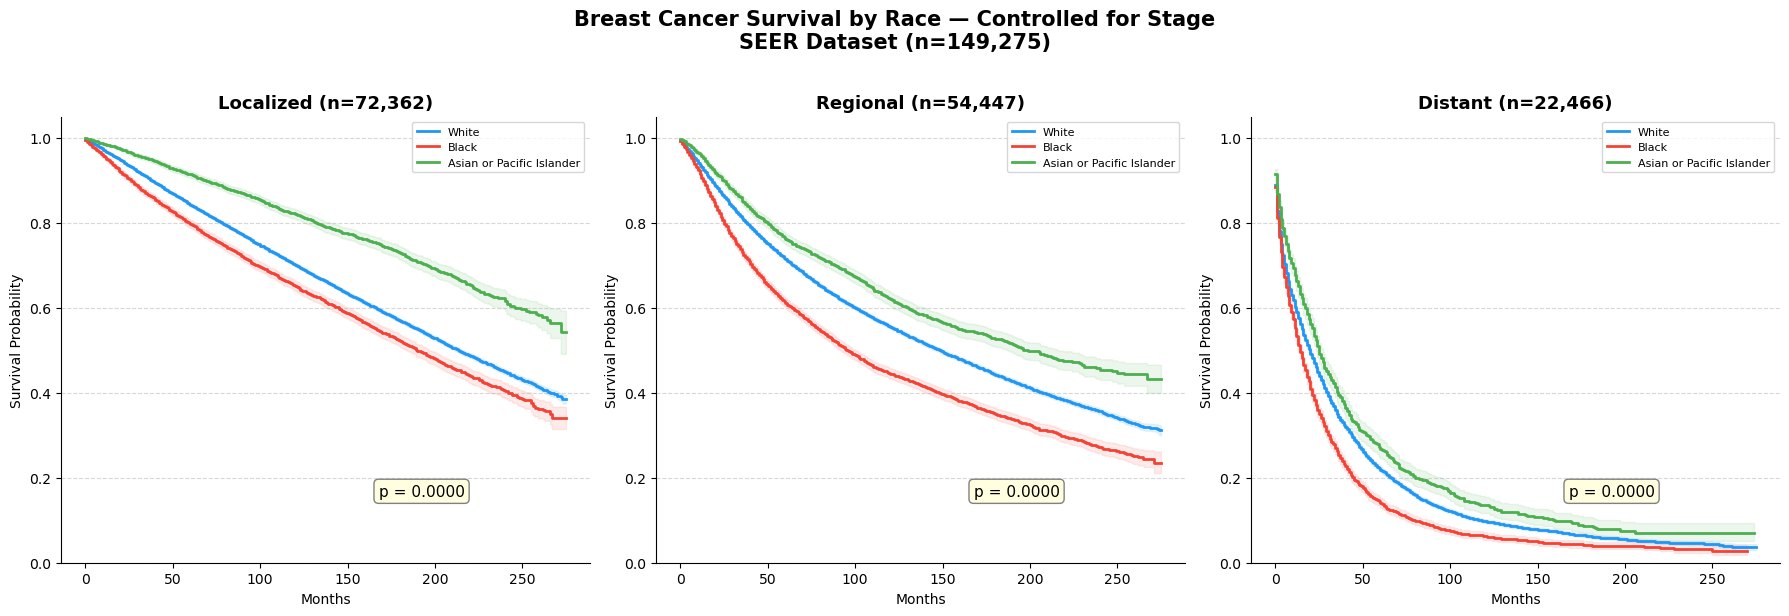

In [15]:
# Remove blank/unknown stages
df_staged = df_clean_seer[
    ~df_clean_seer['stage'].isin(['Blank(s)', 'Unknown/unstaged'])
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

stages = ['Localized', 'Regional', 'Distant']
colors = ['#2196F3', '#F44336', '#4CAF50']
races = ['White', 'Black', 'Asian or Pacific Islander']
labels = ['White', 'Black', 'Asian or Pacific Islander']

for i, stage in enumerate(stages):
    ax = axes[i]
    stage_df = df_staged[df_staged['stage'] == stage]
    
    kmf = KaplanMeierFitter()
    for race, color, label in zip(races, colors, labels):
        mask = stage_df['race'] == race
        group = stage_df[mask]
        if len(group) < 10:
            continue
        kmf.fit(group['survival_months'],
                event_observed=group['event'],
                label=label)
        kmf.plot_survival_function(ax=ax, color=color, linewidth=2, ci_alpha=0.1)
    
    # Log rank test
    stage_races = stage_df[stage_df['race'].isin(races)]
    results = multivariate_logrank_test(
        stage_races['survival_months'],
        stage_races['race'],
        stage_races['event']
    )
    
    ax.annotate(f'p = {results.p_value:.4f}',
                xy=(0.6, 0.15), xycoords='axes fraction',
                fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
    
    n = len(stage_df)
    ax.set_title(f'{stage} (n={n:,})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Months', fontsize=10)
    ax.set_ylabel('Survival Probability', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)

plt.suptitle('Breast Cancer Survival by Race — Controlled for Stage\nSEER Dataset (n=149,275)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Rishit\Projects\Cancer-Analysis\figures\seer_survival_by_race_and_stage.png', 
            dpi=150, bbox_inches='tight')
plt.show()